**<center><font size=5>Building a CNN architecture on our own Dataset</font></center>**

---

**Table of Contents**

- <a href='#intro'>1. Project Overview and Objectives</a>
  - <a href='#dataset'>1.1. Data Set Description</a>
  - <a href='#tumor'>1.2. What is Brain Tumor?</a>
- <a href='#env'>2. Setting up the Environment</a>
- <a href='#import'>3. Data Import</a>
- <a href='#Pre'>4. Load Pretrained Model - The EfficientNETB0 revolution</a>
- <a href='#cnn'>4. Building the AI model</a>
- <a href='#cnn'>5. Model evaluation</a>
- <a href='#concl'>6. Testing the model</a>
- <a href='#concl'>7. Conclusion</a>


# Introduction

Welcome to our 4th notebook of the week .This guide is designed to help you build your own machine learning model for medical imaging diagnosis, starting with brain tumor detection. The structure of this notebook is organized into modular building blocks, allowing you to easily adapt and apply this workflow to other projects, such as heart disease classification, by modifying specific sections.


# <a id='intro'>1. Project Overview and Objectives</a>

The main purpose of this project was to build a Hybrid model using CNN and EfficientNETB0 (Finetuning) that would classify if subject has a tumor (glioma_tumor or meningioma_tumor or pituitary_tumor ) or not based on MRI scan.

## <a id='dataset'>1.1. Data Set Description</a>

The image data that was used for this problem is [Brain MRI Images for Brain Tumor Detection](https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri). It conists of MRI scans of 4 classes:

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

Unfortunately, the data set description doesn't hold any information where this MRI scans come from and so on.

## <a id='tumor'>1.2. What is Brain Tumor?</a>

> A brain tumor occurs when abnormal cells form within the brain. There are two main types of tumors: cancerous (malignant) tumors and benign tumors. Cancerous tumors can be divided into primary tumors, which start within the brain, and secondary tumors, which have spread from elsewhere, known as brain metastasis tumors. All types of brain tumors may produce symptoms that vary depending on the part of the brain involved. These symptoms may include headaches, seizures, problems with vision, vomiting and mental changes. The headache is classically worse in the morning and goes away with vomiting. Other symptoms may include difficulty walking, speaking or with sensations. As the disease progresses, unconsciousness may occur.
>
> ![](https://upload.wikimedia.org/wikipedia/commons/5/5f/Hirnmetastase_MRT-T1_KM.jpg)
>
> _Brain metastasis in the right cerebral hemisphere from lung cancer, shown on magnetic resonance imaging._

Source: [Wikipedia](https://en.wikipedia.org/wiki/Brain_tumor)


# <a id='intro'>2. Setting up the Environment: Import Statements</a>


In [ ]:
# Import Module
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import (
    Dense,
    Input,
    Activation,
    add,
    Add,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
)
from keras.models import Sequential, Model
from keras import optimizers

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# <a id='import'>3. Data Import</a>

When working on different projects, you will need to load a different dataset. The best way to load a dataset is as follows:

(a) Upload the dataset to Google Drive

(b) The image path will be `/content/drive/My Drive/name_of_your_dataset`

(c) Install it on your local machine and put it in your folder and work with it


In [59]:
dataset_path = "BrainMRI_Data/Training"

img_size = (224, 224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    label_mode="int",
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(class_names)

Found 2870 files belonging to 4 classes.
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [60]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "./BrainMRI_Data/Testing",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    label_mode="int",
)

Found 394 files belonging to 4 classes.


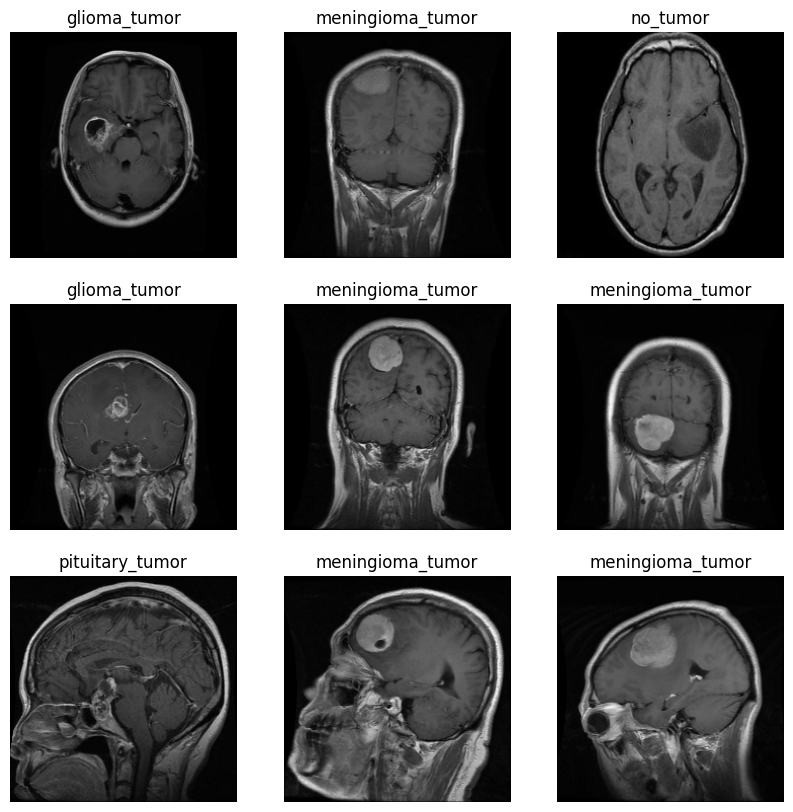

In [61]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [62]:
import numpy as np
from collections import Counter

label_list = []

for images, labels in train_dataset:
    label_list.extend(labels.numpy())

counter = Counter(label_list)

for class_index, count in counter.items():
    print(f"{class_names[class_index]} : {count}")

glioma_tumor : 826
meningioma_tumor : 822
pituitary_tumor : 827
no_tumor : 395


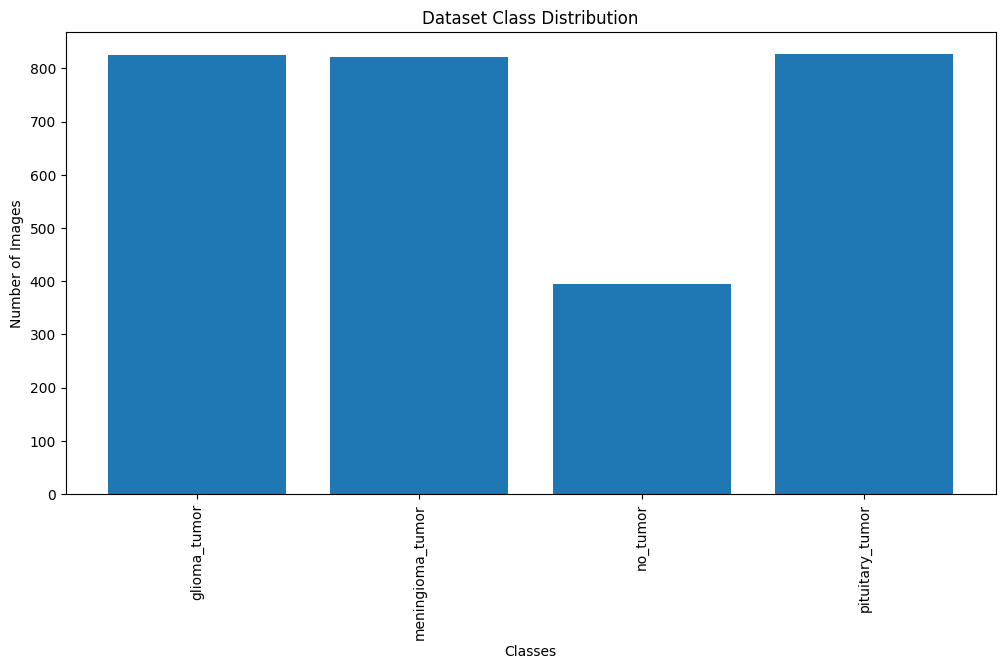

In [ ]:
import matplotlib.pyplot as plt

counts = [counter[i] for i in range(len(class_names))]

plt.figure(figsize=(12, 6))
plt.bar(class_names, counts)
plt.xticks(rotation=90)
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Classes")
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []

for _, y in train_dataset:
    labels.extend(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(labels), y=labels
)
# we tell the model to focus on the imbalanced category ! and you can see in the model evaluation the results are still not good enough !!

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: 0.8686440677966102, 1: 0.8728710462287105, 2: 1.8164556962025316, 3: 0.8675937122128174}


# <a id='intro'>3. Data Processing</a>


In [65]:
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [66]:
for image_batch, labels_batch in train_dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.shape)

(32, 224, 224, 3)
(32,)


# <a href='#Pre'>4. Load Pretrained Model - The EfficientNETB0 revolution</a>


In [ ]:
# Create Model
model_ENB0 = EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(224, 224, 3)
)
model_ENB0.trainable = False
model_ENB0.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_9 (Rescaling)        (None, 224, 224, 3)  0           ['input_10[0][0]']               
                                                                                                  
 normalization_3 (Normalization  (None, 224, 224, 3)  7          ['rescaling_9[0][0]']            
 )                                                                                                
                                                                                     

Three key decisions are made here:

- **include_top=False —** :
  We discard EfficientNet's original classification head (the final dense layers designed for ImageNet's 1,000 classes). This leaves only the convolutional feature extractor, which we will attach our own head to, tailored to our 4-class brain MRI task.

- **weights="imagenet" —** :
  The backbone is initialized with weights pre-trained on ImageNet, a dataset of over 14 million images. Even though ImageNet contains everyday photographs rather than medical scans, the low- and mid-level features learned (edges, textures, shapes) transfer remarkably well to MRI images, giving our model a strong starting point without requiring a massive dataset.

- **model_ENB0.trainable = False —** :
  All layers of the backbone are frozen. During this first phase of training, only the new classification head we will add on top will have its weights updated. This protects the pre-trained representations from being overwritten before the head has stabilized, and drastically reduces the number of trainable parameters.

EfficientNetB0 uses a compound scaling strategy: instead of arbitrarily increasing depth, width, or resolution independently, it scales all three dimensions in a principled, balanced way. This makes it significantly more parameter-efficient than architectures like VGG or ResNet at comparable accuracy levels. The input_shape=(224, 224, 3) means the model expects RGB images resized to 224×224 pixels.


# <a id='intro'>5. Building the AI model</a>


## <a id='Model'>4.1. Model Description</a>

In this step, we are constructing an AI Hybrid model that uses a Convolutional Neural Network (CNN) + EfficientNetB0 architecture, which is particularly good for image recognition tasks. Our model begins with a partial unfreezing of the pre-trained EfficientNetB0 backbone, followed by a custom classification head, a data augmentation pipeline, and a carefully tuned optimizer — all working together to adapt the pre-trained network to our brain MRI classification task.

## <a id='Efficient'>4.2 EfficientNET Model</a>

Rather than building a CNN entirely from scratch, we leverage transfer learning by loading a pre-trained EfficientNetB0 backbone — a state-of-the-art convolutional architecture developed by Google that achieves strong accuracy while remaining computationally efficient.

## <a id='ModelE'>4.3 Pooling</a>

Next, we introduce a pooling layer to reduce the dimensionality of the data, which helps the model to focus on the important features, and a dropout layer to prevent overfitting, which is when the model learns the training data too well and performs poorly on new data.

## <a id='ModelE'>4.4 Fully connected layer</a>

After processing through these layers, the data is flattened into a one-dimensional array so it can be fed into densely connected layers, which will make the final decisions about what the patterns represent – in our case, whether there is a tumor or not.

## <a id='ModelE'>4.5 Activation function and optimizer</a>

The last dense layer uses softmax activation to output probabilities for each class, which completes our model architecture. We compile the model with a categorical crossentropy loss function, which is suitable for multi-class classification problems, and choose the Adamax optimizer, an adaptation of the Adam optimizer that is designed to work well with models that have embeddings and sparse data.

<img src="efficientnetb0_finetuning_architecture.svg" alt="CNN Architecture + EfficientNETB0" width="700"/>

Source: [Claude](Generated by claud with my personnalized prompt)


In [ ]:
model_ENB0.trainable = True
for layer in model_ENB0.layers[:-10]:
    layer.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),  # vertical too
        layers.RandomRotation(0.3),
        layers.RandomZoom(0.3),
        layers.RandomContrast(0.2),  # contrast variation
        layers.RandomTranslation(0.1, 0.1),  # small translations
    ]
)

x = data_augmentation(inputs)
x = preprocess_input(x)
x = model_ENB0(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)  # TRY WITH THE MAX POLLING
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

### FINE TUNING LAYERS

We first re-enable training on the entire backbone, then immediately freeze all layers except the last 10. This two-line pattern is the standard way to perform selective fine-tuning in Keras: trainable = True unlocks the model object, and the loop re-freezes everything up to the final block.

The motivation is to keep the early layers — which have learned general low-level features like edges and textures from ImageNet — completely intact, while allowing the last few layers to adapt their higher-level representations to the specific visual characteristics of brain MRI scans. Unfreezing too many layers on a small medical dataset risks destroying those pre-trained representations through overfitting.

### DATA AUGMENTATION

A strong augmentation pipeline is applied before the backbone sees any image. Each transformation artificially diversifies the training set, making the model more robust to variations it will encounter at inference time:

- **RandomFlip("horizontal_and_vertical") —** Brain MRI slices have no fixed orientation constraint, so both horizontal and vertical flips are anatomically valid augmentations.
- **RandomRotation(0.3) —** Randomly rotates images by up to ~17°, simulating slightly different patient positioning during scanning.
- **RandomZoom(0.3) —** Randomly zooms in or out by up to 30%, helping the model become invariant to the apparent size of structures in the scan.
- **RandomContrast(0.2) —** Varies image contrast, which is important for MRI since scanner settings and tissue properties can produce naturally varying intensities across scans.
- **RandomTranslation(0.1, 0.1) —** Shifts the image by up to 10% in each direction, preventing the model from relying on the exact position of a tumor within the frame.

Augmentation is applied only during training — Keras automatically disables these layers at inference time.

### WHATS THE INPUTS NOW ?

After augmentation, preprocess_input rescales pixel values into the range expected by EfficientNetB0 (trained on ImageNet with specific mean/std normalization). The backbone is then called with training=False, which is the critical setting that tells all BatchNormalization layers inside the backbone to use their learned running statistics rather than computing new statistics from the current batch. Without this, the frozen layers' batch norm behavior becomes unstable and validation metrics become unreliable.

### CLASSIFICATION HEAD

The backbone outputs a 3D feature map which is collapsed into a single vector by Global Average Pooling, averaging each feature channel spatially. This is more parameter-efficient and less prone to overfitting than the alternative of flattening. A dense layer of 256 units then learns task-specific combinations of those features, followed by a Dropout of 0.5 — deliberately high to counter the overfitting risk that comes with a small dataset. The final dense layer produces one probability per class using softmax, making the outputs directly interpretable as class likelihoods.

### COMPILATION

The model is compiled with Adam at a learning rate of 1e-5 — one to two orders of magnitude lower than what would be used when training from scratch. Fine-tuning pre-trained weights requires very small updates; a higher learning rate would overwrite the learned representations before the model has a chance to adapt them. sparse_categorical_crossentropy is used as the loss function because our labels are integers rather than one-hot vectors, which is the standard choice for multi-class classification in this format.


# <a id='intro'>5. Model evaluation</a>


## <a id='intro'>5.1 What does the training process mean?</a>

## Callbacks and Training

Two callbacks are registered to govern the training process automatically, preventing both wasted computation and premature stopping.

### ReduceLROnPlateau

This callback monitors val_loss at the end of every epoch. If no improvement is observed for 4 consecutive epochs, it multiplies the current learning rate by 0.3 — reducing it by 70%. The idea is that a stagnating validation loss often means the optimizer is overshooting the local minimum; a smaller step size lets it settle more precisely. The process can repeat multiple times as training progresses, but min_lr=1e-6 acts as a hard floor so the learning rate never becomes so small that training effectively stops.
The patience of 4 is deliberately set higher than the default (typically 2) to give the optimizer enough room to navigate through short plateaus naturally before resorting to a rate reduction.

### EARLY STOPPING

If val_loss has not improved for 8 consecutive epochs, training is halted entirely. This prevents the model from overfitting by continuing to train long after the point of best generalization. The restore_best_weights=True argument is important: it ensures that when training stops, the model's weights are rolled back to the epoch where val_loss was lowest — not the final epoch, which may already be overfitting.
The patience of 8 is intentionally wider than the ReduceLROnPlateau patience of 4. This creates a two-stage safety net: the learning rate is reduced first at epoch 4 of no progress, giving the model a second chance to improve at a lower rate; only if another 4 epochs pass without improvement does early stopping trigger.

### TRAINING

Training is explicitly pinned to the first GPU using tf.device("/GPU:0"), ensuring all tensor operations are dispatched to the hardware accelerator rather than falling back to the CPU. The model is trained for a maximum of 50 epochs, though early stopping will almost certainly terminate training before that limit is reached.
class_weight is passed to model.fit to address class imbalance in the brain MRI dataset. If one tumor type is significantly more represented than others, the model would naturally bias its predictions toward the majority class. By assigning higher loss weights to underrepresented classes, each sample from a minority class contributes proportionally more to the gradient update, pushing the model to learn all classes equally rather than optimizing for the easiest ones.
The history_finetuning object returned by model.fit records loss, val_loss, accuracy, and val_accuracy at every epoch, which can be plotted afterward to diagnose overfitting, underfitting, or learning rate effects across the training run.


In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.3, patience=4, min_lr=1e-6  # increased
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True  # increased
)

In [ ]:
with tf.device("/GPU:0"):
    history_finetuning = model.fit(
        train_dataset,
        epochs=50,
        validation_data=test_dataset,
        callbacks=[early_stopping, reduce_lr],
        class_weight=class_weights,
    )

Epoch 1/50
90/90 [==============================] - 103s 888ms/step - loss: 1.2433 - accuracy: 0.4704 - val_loss: 1.0520 - val_accuracy: 0.5685 - lr: 1.0000e-05
Epoch 2/50
90/90 [==============================] - 57s 622ms/step - loss: 0.8718 - accuracy: 0.6909 - val_loss: 0.9121 - val_accuracy: 0.6751 - lr: 1.0000e-05
Epoch 3/50
90/90 [==============================] - 50s 555ms/step - loss: 0.6758 - accuracy: 0.7693 - val_loss: 0.8462 - val_accuracy: 0.6929 - lr: 1.0000e-05
Epoch 4/50
90/90 [==============================] - 47s 518ms/step - loss: 0.5503 - accuracy: 0.8143 - val_loss: 0.8239 - val_accuracy: 0.7005 - lr: 1.0000e-05
Epoch 5/50
90/90 [==============================] - 56s 623ms/step - loss: 0.4851 - accuracy: 0.8303 - val_loss: 0.8094 - val_accuracy: 0.7056 - lr: 1.0000e-05
Epoch 6/50
90/90 [==============================] - 44s 488ms/step - loss: 0.4327 - accuracy: 0.8439 - val_loss: 0.8069 - val_accuracy: 0.7107 - lr: 1.0000e-05
Epoch 7/50
90/90 [=====================

## <a id='intro'>5.2 Plotting losses</a>

The plot shows the model's loss on the test set and the validation set over the course of training epochs. The 'loss' refers to the value that a machine learning model tries to minimize during training. In this context, 'test loss' typically would refer to the loss calculated on a separate test set that is not used during the training process, whereas 'validation loss' refers to the loss calculated on a validation set, which is used to monitor and tune the model's performance during training.

In the plot shown, initially the model has decreased for a bit , but as we see the train loss is good (means the model is learning perfectly) but for the validation loss it's not the case (means that our model is suffering to generalize) same for accuracy in the training it's pretty great but for the validation (or test) it shows that the model has learned (okay) but he's making terrible mistakes in the test set which he never saw before

If we adapt this exact model to another dataset for exemple the BRAIN MRI (but with simple TUMOR or NO TUMOR (0,1)) the results would be much better ! and that's because the data isn't enough + ITS INBALANCED UNFORTUNATLLY - So I'll give you a link to another dataset and you can test it and share with me the results and evaluations


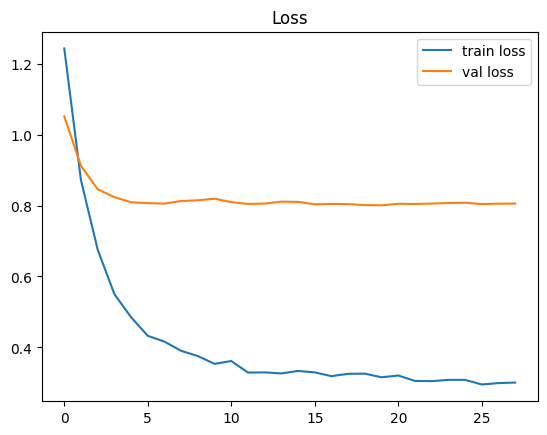

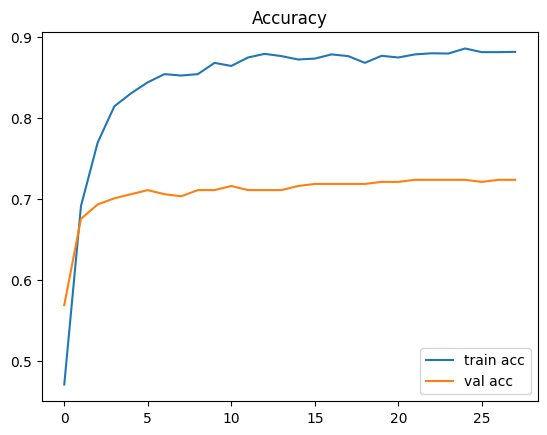

In [108]:
# Learning plots
plt.plot(history_finetuning.history["loss"], label="train loss")
plt.plot(history_finetuning.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history_finetuning.history["accuracy"], label="train acc")
plt.plot(history_finetuning.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

# <a id='intro'>6. Testing the model</a>

In the testing phase of our machine learning project, we evaluate the model's performance using new images it hasn't seen before. The code snippet demonstrates how to test the model with an MRI image that has a tumor and one which does not have a tumor.

The process involves loading the image, resizing it to match the input size the model expects, and then reshaping it to the appropriate format for the model to process. The model then predicts whether a tumor is present or not.

The result, displayed below the image, shows the model's confidence level in its prediction.

- As you see the model is biased a bit to (Meningioma Tumor) this category , and that's what I told you , the dataset is imbalanced and maybe if we can fight these problems 'with data ofc' we can achieve better results


In [97]:
def class_name(index):

    classes = ["Glioma Tumor", "Meningioma Tumor", "No Tumor", "Pituitary Tumor"]

    return classes[index]

In [109]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_path = "BrainMRI_Data/Testing/pituitary_tumor/image(77).jpg"

img = Image.open(img_path)

# resize comme dans le training
img_resized = img.resize((224, 224))

x = np.array(img_resized)

# normalisation comme dans ton dataset
x = x / 255.0

# ajouter dimension batch
x = x.reshape(1, 224, 224, 3)

# prediction
pred = model.predict(x)

pred_class = np.argmax(pred)

confidence = pred[0][pred_class] * 100

1/1 [==============================] - 1s 1s/step


26.13% Confidence → Meningioma Tumor


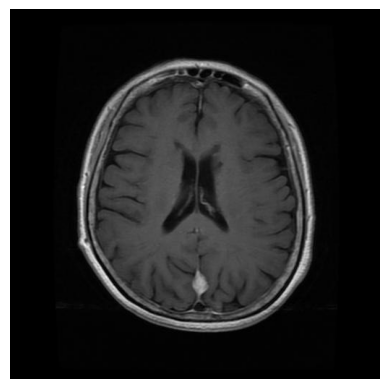

In [112]:
plt.imshow(img)
plt.axis("off")

print(f"{confidence:.2f}% Confidence → {class_name(pred_class)}")

1/1 [==============================] - 0s 33ms/step
26.10% → Meningioma Tumor


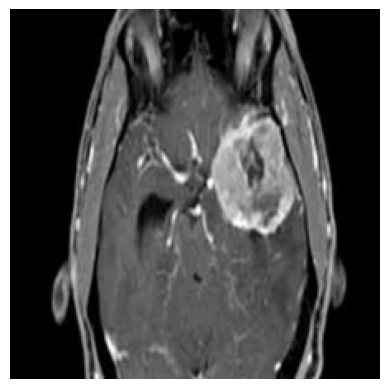

In [119]:
predict_image("BrainMRI_Data/Testing/meningioma_tumor/image(5).jpg")

# <a id='intro'>7. Conclusions</a>

This notebook has guided you through creating a brain tumor classification Hybrid model using a Convolutional Neural Network (CNN) + The EfficientNET pretrained model. We've covered essential steps such as preparing and loading data, designing and training the neural network, and finally testing its ability to classify MRI images (which wasn't perfect , but for this imbalanced dataset it's quite impressive tbh hhh).

**The skills and methods you've learned here aren't limited to just identifying brain tumors—they form the foundation for a wide range of image classification projects. You can apply the same techniques to different types of medical imagery, such as detecting signs of heart disease in echocardiograms or identifying various conditions using X-ray images.**

Remember, the principles of loading your dataset, preprocessing the images, building and training the model, and evaluating its performance are similar, no matter what kind of images you're working with. The "building blocks" we've used can be rearranged and adapted to suit any image classification task you're interested in exploring.

So, take what you've learned and start applying it to new challenges—the possibilities for what you can achieve are as broad as your imagination. Whether it's medical imaging or another field entirely, the tools you've mastered here are a solid foundation for your journey in AI and machine learning. Keep learning, keep building, and have fun exploring the vast potential of these technologies!

Here's the link to the dataset that I've mentionned earlier :
[Brain MRI Images for Brain Tumor Detection](https://www.kaggle.com/navoneel/brain-mri-images-for-brain-tumor-detection). It conists of MRI scans of two classes:

- `NO` - no tumor, encoded as `0`
- `YES` - tumor, encoded as `1`
